In [1]:
import os
os.environ["TQDM_DISABLE"] = "1"
import pandas as pd
import pickle
from pmsi.imputers import (
    locf_imputation_1D, 
    knn_imputation_2D,
    multi_point_linear_imputation_1D
)
from pmsi.pmsi_core import PMSIImputer
from pmsi.visualization import (
    plot_periodicity_percentiles,
    plot_pmsi_kernel,
    plot_data_intuition
)
from pmsi.evaluation import evaluate_method, combine_results
from pathlib import Path
from pmsi.evaluation import combine_results, stratify_results_by_periodicity


import numpy as np
from sklearn.impute import KNNImputer

C:\Users\edan1\workspace\Periodic-Multi-Scale-Imputation\.venv\Lib\site-packages\hyperopt\atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


C:\Users\edan1\workspace\Periodic-Multi-Scale-Imputation\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
N_BOOTSTRAP = 10000
N_PER_KEY = 100

In [3]:
with open('export_distorted.pkl', 'rb') as f:
    export = pickle.load(f)

In [4]:
pivot_d, binary_d, good_k, binary_masks = export["pivot_d"], export["binary_d"], export["good_k"], export["binary_masks"]

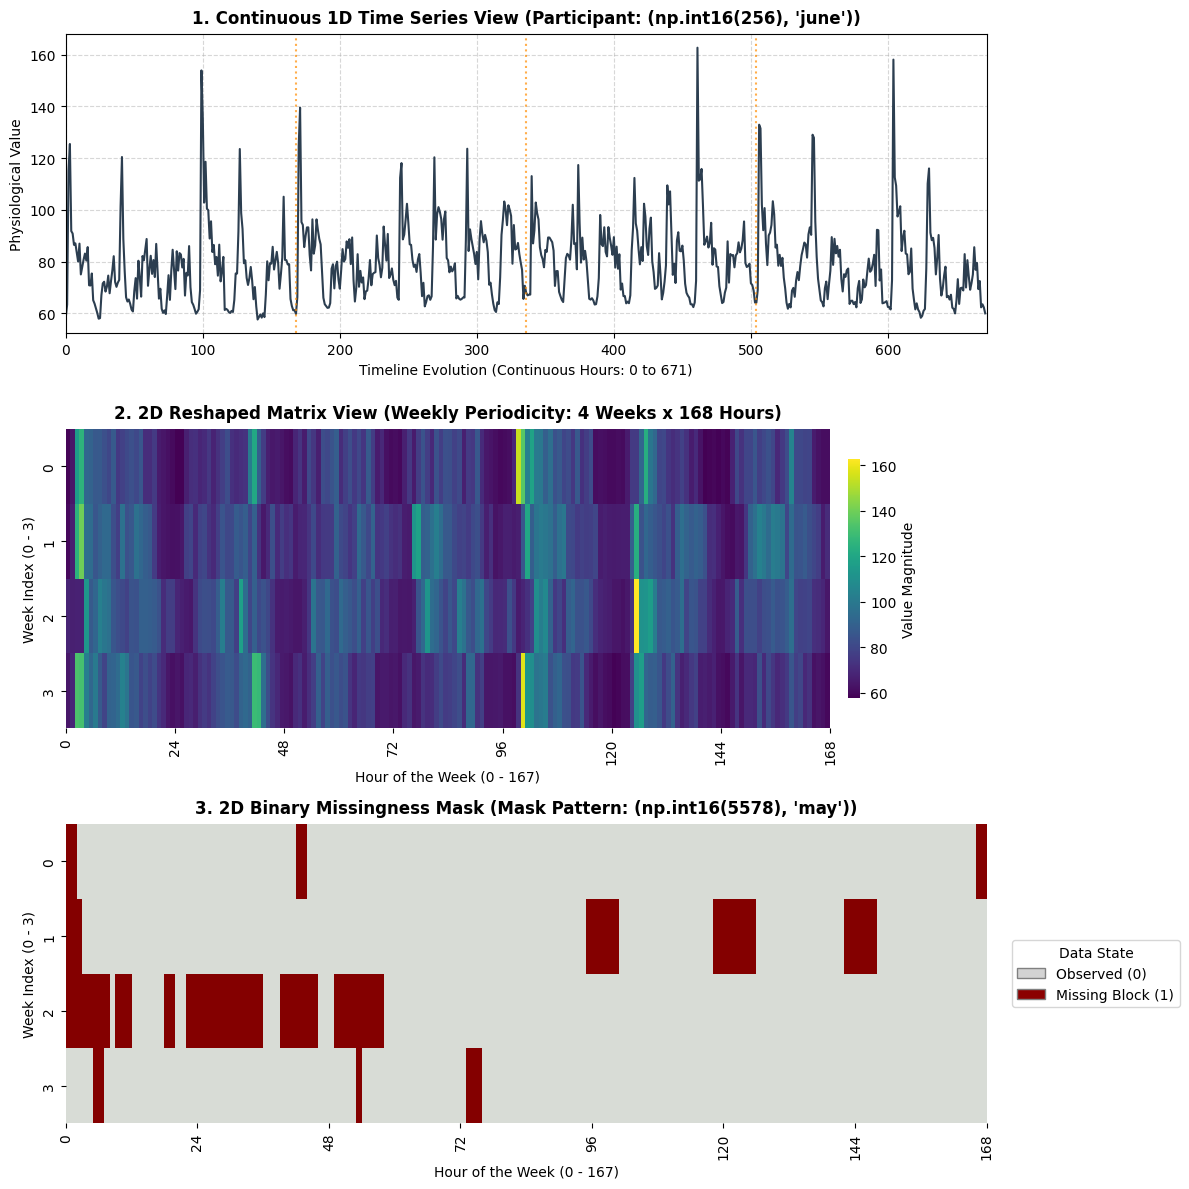

In [5]:
plot_data_intuition(pivot_d, binary_d, good_k, binary_masks)

In [6]:
# 1. Evaluate PMSI (2D)
print("Training PMSI Core...")
pmsi_model = PMSIImputer(n_evals=300)
pmsi_model.fit(pivot_d, binary_d, good_k, binary_masks, n_pairs_per_key=1)

Training PMSI Core...
Fitting PMSI: Running 300 evals via Hyperopt TPE...
  0%|          | 0/300 [00:00<?, ?trial/s, best loss=?]

  1%|          | 3/300 [00:00<00:09, 29.99trial/s, best loss: 179.60805414129766]

  2%|▏         | 7/300 [00:00<00:09, 32.41trial/s, best loss: 178.65628306526594]

  4%|▎         | 11/300 [00:00<00:08, 32.34trial/s, best loss: 178.65628306526594]

  5%|▌         | 15/300 [00:00<00:08, 32.69trial/s, best loss: 177.25962508697657]

...

 97%|█████████▋| 292/300 [00:09<00:00, 30.13trial/s, best loss: 176.6153049086796]

 99%|█████████▊| 296/300 [00:09<00:00, 30.04trial/s, best loss: 176.6153049086796]

100%|██████████| 300/300 [00:09<00:00, 30.53trial/s, best loss: 176.6153049086796]

100%|██████████| 300/300 [00:09<00:00, 30.31trial/s, best loss: 176.6153049086796]


Fit Complete. Optimal Params: {'x': np.float64(0.9773422484809919), 'y': np.float64(2.1504731430225346)} | AIC: 176.62


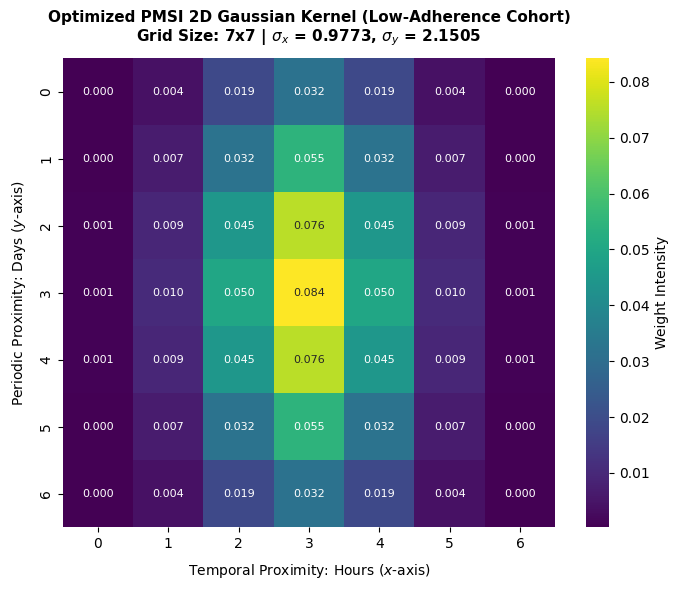

In [7]:
plot_pmsi_kernel(pmsi_model, title_suffix="(Low-Adherence Cohort)")

In [8]:
print("2. Running Benchmarks...")
results = []

2. Running Benchmarks...


In [9]:
print("Evaluating PMSI...")
pmsi_res = evaluate_method(
    name="PMSI", 
    impute_fn=pmsi_model.impute, # Pass the bound method of the fitted class
    seed=42, 
    pivot_d=pivot_d, binary_d=binary_d, good_k=good_k, binary_masks=binary_masks,
    is_2d=True, shape_2d=(28, 24),n_bootstrap=N_BOOTSTRAP,
    n_per_key=N_PER_KEY  
)
results.append(pmsi_res)

Evaluating PMSI...

  METHOD: PMSI    (seed = 42)
  Built 5000 (data, mask) pairs.


  Pairs evaluated:    5000    (skipped: 0)
  Wall-clock runtime:    10.208 s   (2.04 ms/pair)
  Peak Python memory:     3.315 MB  (tracemalloc)
  RSS delta:              0.406 MB  (psutil)

  Bootstrap 95% CIs  (n_replicates = 10000):
  Metric         Mean    95% CI                      
  -------  ----------    ----------------------------


  RMSE         8.6342    [    8.5323,     8.7351]


  MAE          6.4348    [    6.3682,     6.5016]


  MAPE         8.9778    [    8.8790,     9.0763]


  SMAPE        8.9884    [    8.8954,     9.0845]


  Bias         0.2391    [    0.1472,     0.3337]


  MedAE        5.0000    [    4.9403,     5.0613]


In [10]:
# 2. Evaluate LOCF (1D)
locf_res = evaluate_method(
    name="LOCF", 
    impute_fn=locf_imputation_1D,
    seed=42, 
    pivot_d=pivot_d, 
    binary_d=binary_d, 
    good_k=good_k, 
    binary_masks=binary_masks,
    is_2d=False,
    n_bootstrap=N_BOOTSTRAP,
    n_per_key=N_PER_KEY                    
)
results.append(locf_res)


  METHOD: LOCF    (seed = 42)
  Built 5000 (data, mask) pairs.


  Pairs evaluated:    5000    (skipped: 0)
  Wall-clock runtime:     8.059 s   (1.61 ms/pair)
  Peak Python memory:     3.294 MB  (tracemalloc)
  RSS delta:              0.449 MB  (psutil)

  Bootstrap 95% CIs  (n_replicates = 10000):
  Metric         Mean    95% CI                      
  -------  ----------    ----------------------------


  RMSE        13.2766    [   13.1179,    13.4347]


  MAE         10.2936    [   10.1750,    10.4138]


  MAPE        14.8878    [   14.6887,    15.0910]


  SMAPE       14.1145    [   13.9515,    14.2811]


  Bias         2.3054    [    2.1305,     2.4822]


  MedAE        8.4389    [    8.3229,     8.5571]


In [11]:
# 3. Evaluate PLI (1D)
res_linear = evaluate_method(
    "PLI", multi_point_linear_imputation_1D, seed=42,
    pivot_d=pivot_d, binary_d=binary_d,
    good_k=good_k, binary_masks=binary_masks,
    is_2d=False, impute_kwargs={"window_size": 7},
    n_bootstrap=N_BOOTSTRAP,
    n_per_key=N_PER_KEY
)
results.append(res_linear)


  METHOD: PLI    (seed = 42)
  Built 5000 (data, mask) pairs.


  Pairs evaluated:    5000    (skipped: 0)
  Wall-clock runtime:    10.270 s   (2.05 ms/pair)
  Peak Python memory:     3.181 MB  (tracemalloc)
  RSS delta:              0.520 MB  (psutil)

  Bootstrap 95% CIs  (n_replicates = 10000):
  Metric         Mean    95% CI                      
  -------  ----------    ----------------------------


  RMSE        11.0495    [   10.9145,    11.1850]


  MAE          8.5011    [    8.4032,     8.5995]


  MAPE        12.5036    [   12.3289,    12.6784]


  SMAPE       11.7696    [   11.6264,    11.9116]


  Bias         2.2364    [    2.0970,     2.3747]


  MedAE        6.8127    [    6.7245,     6.9015]


In [12]:
# 3. Evaluate KNN (2D)
knn_res = evaluate_method(
    name="KNN", 
    impute_fn=knn_imputation_2D,   
    seed=42, 
    pivot_d=pivot_d, 
    binary_d=binary_d, 
    good_k=good_k, 
    binary_masks=binary_masks,
    is_2d=True,                   
    shape_2d=(28, 24),
    n_bootstrap=N_BOOTSTRAP,
    n_per_key=N_PER_KEY
)
results.append(knn_res)


  METHOD: KNN    (seed = 42)
  Built 5000 (data, mask) pairs.


  Pairs evaluated:    5000    (skipped: 0)
  Wall-clock runtime:   108.456 s   (21.69 ms/pair)
  Peak Python memory:     3.278 MB  (tracemalloc)
  RSS delta:              0.203 MB  (psutil)

  Bootstrap 95% CIs  (n_replicates = 10000):
  Metric         Mean    95% CI                      
  -------  ----------    ----------------------------


  RMSE         9.6180    [    9.5232,     9.7141]


  MAE          7.5727    [    7.5067,     7.6395]


  MAPE        10.8699    [   10.7616,    10.9775]


  SMAPE       10.6749    [   10.5735,    10.7739]


  Bias         0.4597    [    0.3422,     0.5737]


  MedAE        6.5632    [    6.4990,     6.6290]


In [13]:
print("3. Aggregating Results...")
summary_dataframes = combine_results(results, output_dir="./benchmark_outputs")

3. Aggregating Results...

  COMBINED SUMMARY  (all methods, all metrics)
Method  seed  RMSE_mean            RMSE_CI  MAE_mean             MAE_CI  MAPE_mean            MAPE_CI  SMAPE_mean           SMAPE_CI  Bias_mean          Bias_CI  MedAE_mean         MedAE_CI
  PMSI    42     8.6342   [8.5323, 8.7351]    6.4348   [6.3682, 6.5016]     8.9778   [8.8790, 9.0763]      8.9884   [8.8954, 9.0845]     0.2391 [0.1472, 0.3337]      5.0000 [4.9403, 5.0613]
  LOCF    42    13.2766 [13.1179, 13.4347]   10.2936 [10.1750, 10.4138]    14.8878 [14.6887, 15.0910]     14.1145 [13.9515, 14.2811]     2.3054 [2.1305, 2.4822]      8.4389 [8.3229, 8.5571]
   PLI    42    11.0495 [10.9145, 11.1850]    8.5011   [8.4032, 8.5995]    12.5036 [12.3289, 12.6784]     11.7696 [11.6264, 11.9116]     2.2364 [2.0970, 2.3747]      6.8127 [6.7245, 6.9015]
   KNN    42     9.6180   [9.5232, 9.7141]    7.5727   [7.5067, 7.6395]    10.8699 [10.7616, 10.9775]     10.6749 [10.5735, 10.7739]     0.4597 [0.3422, 0.5737]      

4. Stratifying Errors by Weekly Periodicity (ACF)...


C:\Users\edan1\workspace\Periodic-Multi-Scale-Imputation\.venv\Lib\site-packages\statsmodels\tsa\stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


5. Generating Figure 3...


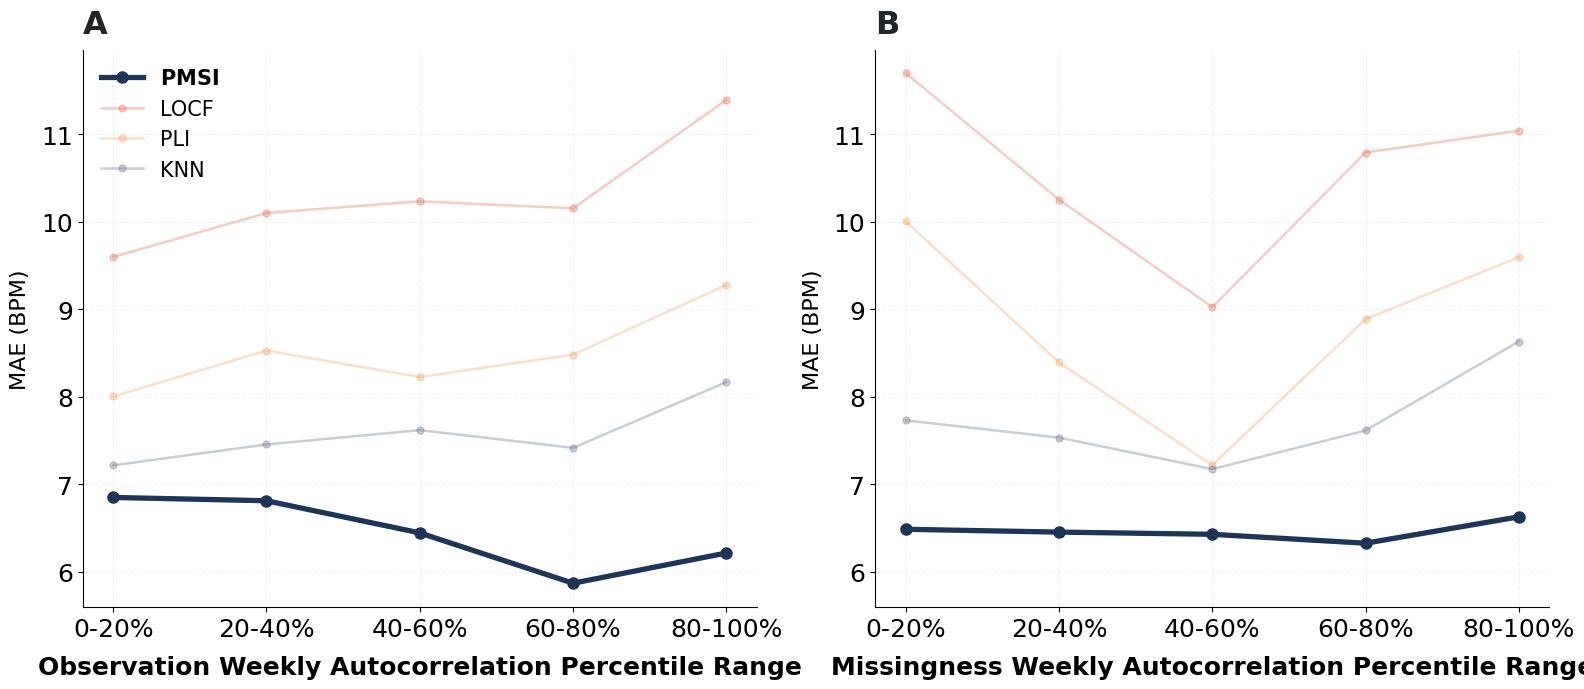

In [14]:
print("4. Stratifying Errors by Weekly Periodicity (ACF)...")
formatted_results = stratify_results_by_periodicity(results, pivot_d, binary_d, good_k)

print("5. Generating Figure 3...")
plot_periodicity_percentiles(formatted_results)